In [1]:
from mosep_analysis.data import config
from mosep_analysis.data.config import TARGET_EXTENTS_VIF, TARGET_EXTENTS_VIF_SPLITS, ROOF_EXTENT, TARGET_DISTANCES
from moseplib.data.utils import flatten_multiindex
from moseplib.data import pointcloud_processing, pc_statistics

import pandas as pd
import pickle

from matplotlib import pyplot as plt
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from IPython.display import display, Latex

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Load Met Data from Bagfile

In [2]:
BAG_NAMES = [
    "molisens_met_2023_08_07-15_36_45_converted",  # reference
    "molisens_met_2023_08_28-21_40_13_converted",  # 8
    "molisens_met_2023_08_29-06_04_46_converted",  # 12
    "molisens_met_2023_08_29-08_21_47_converted",  # 17
    "molisens_met_2023_08_29-13_41_50_converted",  # 27
    "molisens_met_2023_08_29-16_58_02_converted",  # 31
    "molisens_met_2023_08_29-17_58_33_converted",  # 32
    "molisens_met_2023_09_23-06_39_11_converted",  # 95
]
PICKLE_DATA_DIR = config.PROCESSED_DATA_FOLDER

In [ ]:
# TODO: here it could be ok to directly load the met data.

RESAMPLE_FREQ = "1min"
columns_and_aggregation = {
    ("precipitation", "intensity_hour_shifted"): "first",
    ("precipitation", "intensity_hour"): "first",
    ("precipitation", "differential"): "sum",
    ("precipitation", "total_precipitation_particles"): "sum",
    ("precipitation", "total_drops"): "sum",
    ("wind", "speed_avg"): "mean",
    ("temperature", "average"): "mean",
    ("humidity", "relative_avg"): "mean",
    ("pressure", "relative_avg"): "mean",
    ("radiation", "current"): "mean",
}

files = [PICKLE_DATA_DIR / f"weather_df_{bag_name}.pickle" for bag_name in BAG_NAMES]

dfs = {}
df_relevant_all = {}
for file in files:
    with open(file, "rb") as f:
        df = pickle.load(f)

    basename = "_".join(file.stem.split("_")[4:-1])
    dfs[basename] = df

    df_relevant = df.loc[:, columns_and_aggregation.keys()]

    columns = flatten_multiindex(df_relevant)
    df_relevant = df_relevant.resample(RESAMPLE_FREQ).agg({".".join(k): v for k, v in columns_and_aggregation.items()})
    df_relevant.columns = columns_and_aggregation.keys()
    df_relevant_all[basename] = df_relevant

df = pd.concat(dfs, axis=0)
df_relevant = pd.concat(df_relevant_all, axis=0)

In [4]:
df_relevant

precipitation                 \
                                        intensity_hour_shifted intensity_hour   
                    Timestamp                                                   
2023_08_07-15_36_45 2023-08-07 13:36:00                   0.00           0.00   
                    2023-08-07 13:37:00                   0.00           0.00   
                    2023-08-07 13:38:00                   0.00           0.00   
                    2023-08-07 13:39:00                   0.00           0.00   
2023_08_28-21_40_13 2023-08-28 19:40:00                   0.63           2.07   
...                                                        ...            ...   
2023_09_23-06_39_11 2023-09-23 05:13:00                   0.54           0.79   
                    2023-09-23 05:14:00                   0.74           0.54   
                    2023-09-23 05:15:00                   1.04           0.74   
                    2023-09-23 05:16:00                   0.47           1.04   
                    2023-09-23 05:17:00                   0.00           0.47   

                                                      \
                                        differential   
                    Timestamp                          
2023_08_07-15_36_45 2023-08-07 13:36:00         0.00   
                    2023-08-07 13:37:00         0.00   
                    2023-08-07 13:38:00         0.00   
                    2023-08-07 13:39:00         0.00   
2023_08_28-21_40_13 2023-08-28 19:40:00         0.00   
...                                              ...   
2023_09_23-06_39_11 2023-09-23 05:13:00         0.01   
                    2023-09-23 05:14:00         0.02   
                    2023-09-23 05:15:00         0.00   
                    2023-09-23 05:16:00         0.01   
                    2023-09-23 05:17:00         0.00   

                                                                       \
                                        total_precipitation_particles   
                    Timestamp                                           
2023_08_07-15_36_45 2023-08-07 13:36:00                           0.0   
                    2023-08-07 13:37:00                           0.0   
                    2023-08-07 13:38:00                           0.0   
                    2023-08-07 13:39:00                           0.0   
2023_08_28-21_40_13 2023-08-28 19:40:00                          28.0   
...                                                               ...   
2023_09_23-06_39_11 2023-09-23 05:13:00                          53.0   
                    2023-09-23 05:14:00                          50.0   
                    2023-09-23 05:15:00                          61.0   
                    2023-09-23 05:16:00                          61.0   
                    2023-09-23 05:17:00                          21.0   

                                                         wind temperature  \
                                        total_drops speed_avg     average   
                    Timestamp                                               
2023_08_07-15_36_45 2023-08-07 13:36:00         0.0  2.244331   19.000683   
                    2023-08-07 13:37:00         0.0  2.124639   19.004206   
                    2023-08-07 13:38:00         0.0  1.927533   19.019649   
                    2023-08-07 13:39:00         0.0  1.790939   19.035237   
2023_08_28-21_40_13 2023-08-28 19:40:00         1.0  1.168022   18.762622   
...                                             ...       ...         ...   
2023_09_23-06_39_11 2023-09-23 05:13:00        12.0  1.327593   16.045167   
                    2023-09-23 05:14:00        17.0  1.284531   16.020197   
                    2023-09-23 05:15:00        10.0  1.233068   15.989582   
                    2023-09-23 05:16:00         7.0  1.141167   15.959743   
                    2023-09-23 05:17:00         6.0  1.101099   15.939108   

                           

## Load PC data

In [5]:
# load from pickle and merge datasets
path = config.PROCESSED_DATA_FOLDER / f"rain_minutes_{BAG_NAMES[0]}.pickle"
with open(path, "rb") as handle:
    ds_minutes = pickle.load(handle)

for bag_name in BAG_NAMES[1:]:
    path = config.PROCESSED_DATA_FOLDER / f"rain_minutes_{bag_name}.pickle"
    with open(path, "rb") as handle:
        ds_dict = pickle.load(handle)
    for stat, ds in ds_minutes.items():
        ds = ds.extend(ds_dict[stat])

In [6]:
TIME_AGGREGATION = "sum"
SPACE_AGGREGATION = pc_statistics.mean_intensity

In [7]:
subtarget_statistics = pointcloud_processing.subset_and_aggregate_dataset(
    dataset=ds_minutes[TIME_AGGREGATION],
    splits=TARGET_EXTENTS_VIF_SPLITS,
    agg_func=SPACE_AGGREGATION,
    return_type="df",
)
subtarget_statistics.columns.names = ["target", "color"]

In [8]:
subtarget_statistics

target                   Target-01                                 Target-02  \
color                        white          grey        black          white   
2023-08-07 13:37:00  116033.828125  50181.707031  8380.512695  257484.500000   
2023-08-07 13:38:00  135104.984375  57453.078125  9751.884766  301888.437500   
2023-08-07 13:39:00  106689.757812  45465.089844  7811.858887  242775.328125   
2023-08-28 19:40:00   43109.691406  14721.476562  2003.602539   77752.109375   
2023-08-28 19:41:00  134555.062500  46085.226562  6481.769043  253941.718750   
...                            ...           ...          ...            ...   
2023-09-23 05:13:00  117046.601562  43900.910156  4115.063477  288716.937500   
2023-09-23 05:14:00  117505.570312  43929.097656  4263.303711  294389.781250   
2023-09-23 05:15:00  117710.351562  44164.878906  4368.734375  297403.343750   
2023-09-23 05:16:00  117436.007812  44245.843750  4346.886230  296198.937500   
2023-09-23 05:17:00   40118.550781  15059.417969  1482.683594  101940.390625   

target                                                Target-03  \
color                         grey         black          white   
2023-08-07 13:37:00  112234.718750  20312.175781   76292.429688   
2023-08-07 13:38:00  131474.062500  23857.117188   89472.140625   
2023-08-07 13:39:00  105585.445312  19284.117188   70544.289062   
2023-08-28 19:40:00   46716.554688   7401.470703   36355.875000   
2023-08-28 19:41:00  154398.562500  25191.765625  120005.375000   
...                            ...           ...            ...   
2023-09-23 05:13:00  124572.445312   9262.437500  132029.500000   
2023-09-23 05:14:00  131831.937500   9953.250000  133970.625000   
2023-09-23 05:15:00  134679.062500  10437.562500  135339.875000   
2023-09-23 05:16:00  133483.671875  10159.000000  136215.625000   
2023-09-23 05:17:00   46662.277344   3640.000000   46969.500000   

target                                               Target-04                \
color                         grey         black         white          grey   
2023-08-07 13:37:00   58159.539062  55374.699219  59651.667969  27257.000000   
2023-08-07 13:38:00   68227.765625  64970.000000  70908.664062  32258.000000   
2023-08-07 13:39:00   54058.921875  51256.500000  57331.332031  26291.000000   
2023-08-28 19:40:00   28808.785156  22515.214844  10081.000000   4398.333496   
2023-08-28 19:41:00   96045.289062  74892.640625  33788.167969  14690.000000   
...                            ...           ...           ...           ...   
2023-09-23 05:13:00  100073.929688  78061.570312  60409.500000  27124.333984   
2023-09-23 05:14:00  102616.289062  79822.000000  60082.000000  28293.000000   
2023-09-23 05:15:00  104230.859375  80955.140625  60336.167969  26907.000000   
2023-09-23 05:16:00  105164.789062  81936.500000  60112.832031  26775.666016   
2023-09-23 05:17:00   36558.070312  28445.572266  20458.000000   9219.000000   

target                            Target-05                              
color                      black      white          grey         black  
2023-08-07 13:37:00          NaN  29933.500  11155.833008    600.400024  
2023-08-07 13:38:00          NaN  35454.500  13341.500000    618.500000  
2023-08-07 13:39:00          NaN  28499.000  10792.166992    437.166656  
2023-08-28 19:40:00          NaN  12039.375   3377.571533   9592.857422  
2023-08-28 19:41:00  3608.000000  40842.125  11423.000000  31926.285156  
...                          ...        ...           ...           ...  
2023-09-23 05:13:00  6231.750000  48663.500  13696.500000  48145.625000  
2023-09-23 05:14:00  6321.666504  52703.500  12255.000000  50575.125000  
2023-09-23 05:15:00  6671.333496  55403.250  13168.000000  53817.625000  
2023-09-23 05:16:00  6617.000000  58179.000  16101.000000  53241.875000  
2023-09-23 05:17:00  1731.000000  20414.500   5783.500000  17597.375000  

[430 rows x 15 columns]

### Plot relations

In [9]:
# x inten
# y rain rate
# color reflect
# symbol range

regression_data = subtarget_statistics.melt(
    value_name="intensity", ignore_index=False
)  # .reset_index(names="datetime")
regression_data["range"] = regression_data["target"].apply(lambda x: TARGET_DISTANCES[x])

df_relevant_flat = df_relevant.copy()
df_relevant_flat.columns = [".".join(col) for col in df_relevant.columns]
df_relevant_flat.reset_index(level=0, names="bag_name", inplace=True)
regression_data = regression_data.merge(df_relevant_flat, left_index=True, right_index=True, how="left")


# regression_data["intensity"] = utils.normalize_df(regression_data["intensity"], kind="standard")
# regression_data["precipitation.intensity_hour_shifted"] = utils.normalize_df(
#     regression_data["precipitation.intensity_hour_shifted"], kind="standard"
# )

# Map color to numerical values
color_mapping = {"white": 0.9, "grey": 0.45, "black": 0.06}
regression_data["reflectivity"] = regression_data["color"].map(color_mapping)


regression_data.sort_values(["range", "color"], inplace=True)

In [10]:
px.scatter(
    regression_data,
    x="intensity",
    y="precipitation.intensity_hour_shifted",
    color="color",
    symbol="range",
    height=800,
    width=1600,
    labels={"intensity": "Reflected lidar intensity", "precipitation.intensity_hour_shifted": "Rain Rate [mm/h]"},
)

## Model

intensity = f(range, rain, reflec)

I = a*R+b*D+c*Ref+d  
I = a*R+exp(b*D)+c*Ref+d

I ... Lidar Intensity  
R ... Rainrate or precipitation intensity [mm/h]  
D ... distance to target (range column) [m]  
Ref ... Reflectivity of the target (color column)  
a,b,c,d... coefficents  


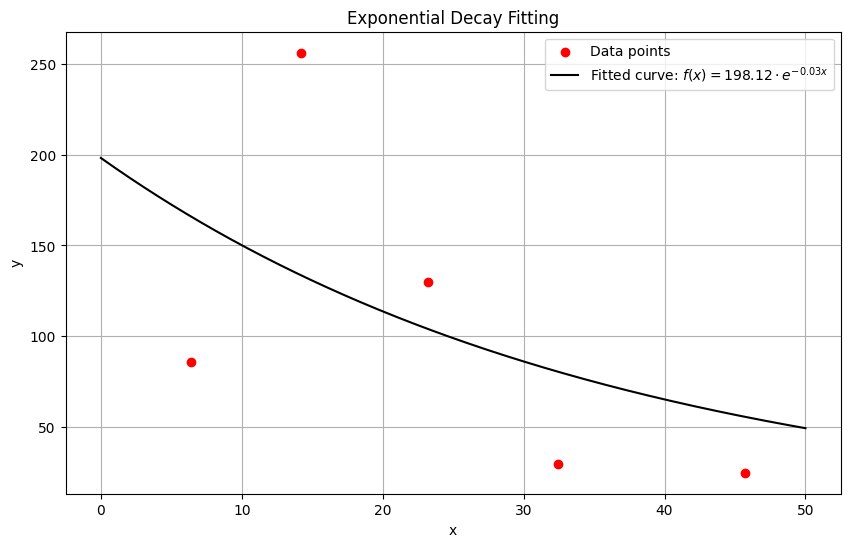

(198.12054895989766, 0.02774158270008774)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data points
x_data = np.array([6.38, 14.2, 23.25, 32.45, 45.7])
y_data = np.array([86, 256, 130, 30, 25])


# Define the exponential decay function
def exp_decay(x, a, b):
    return a * np.exp(-b * x)


# Perform the curve fitting
params, params_covariance = curve_fit(exp_decay, x_data, y_data, p0=[100, 0.1])

# Extract the parameters
a, b = params

# Generate fitted data for plotting
x_fit = np.linspace(0, 50, 400)
y_fit = exp_decay(x_fit, a, b)

# Plot the data points and the fitted curve
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color="red", label="Data points")
plt.plot(x_fit, y_fit, label=f"Fitted curve: $f(x) = {a:.2f} \cdot e^{{-{b:.2f} x}}$", color="black")
plt.title("Exponential Decay Fitting")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# Display the fitted parameters
a, b

In [12]:
# Test model and initial parameters


def model_func(X, a1, a2, b, c1, c2, d):
    r, refelctivity, rainrate = X
    return (
        (a1 * np.exp(-a2 * X[r]))
        + (b * X[refelctivity] / (X[r] ** 2))
        + (c1 ** X[rainrate] ** 2 + c2 * X[rainrate])
        + d
    )
    # a[0] * np.exp(-a[1] * X[r]) * b * X[refelctivity] + c * X[rainrate] # [0.34, 0.077]
    # a1 * np.exp(-a2 * X[r]) + a3 + (b1 * X[refelctivity] / (b2 * X[r])) + (c * X[rainrate])


# plot_data = regression_data[(regression_data["color"] == "white")]
plot_data = regression_data.reset_index(names="timestamp")

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=plot_data.index,
        y=plot_data["precipitation.intensity_hour_shifted"],
        mode="lines",
        name="Rainfall Rate",
    )
)
fig.add_trace(
    go.Scatter(
        x=plot_data.index,
        y=plot_data["intensity"],
        mode="markers",
        name="Target Intensity",
        text=plot_data["target"],
        marker=dict(size=5, color=plot_data["color"]),
    )
)
fig.add_trace(
    go.Scatter(
        x=plot_data.index,
        y=model_func(
            plot_data[["range", "reflectivity", "precipitation.intensity_hour_shifted"]],
            400,
            0.1,
            20000000,
            0.8,
            -500,
            10000.0,
        ),
        mode="lines",
        name="model",
    )
)
fig.update_layout(height=800, width=1600)

In [13]:
def get_formula(coeffs, features):
    for i, (_, co) in enumerate(zip(features, coeffs)):
        for k, v in formula_map.items():
            features[i] = features[i].replace(k, v)
        features[i] = features[i].replace(" ", " \cdot ")
        features[i] = f"{co:.2f} \cdot {features[i]}"

    return f"$f(r, beta, RR) = {(' + ').join(features)}$"

In [14]:
from scipy.optimize import curve_fit

# Sample data loading
model_data = regression_data.reset_index(names="timestamp").dropna()
model_data = model_data[model_data["target"] != "Target-01"]

# Handle missing values in intensity
# model_data["intensity"].interpolate(method="linear", inplace=True)

# Prepare the data for curve fitting
X = model_data[["range", "reflectivity", "precipitation.intensity_hour_shifted"]]
y = model_data["intensity"]
formula_map = {
    "range": "r",
    "reflectivity": "beta",
    "precipitation.intensity_hour_shifted": "RR",
    "intensity": "I",
}

model_results = {}

## Curve Fitting
# Initial guess for the parameters
initial_guess = [
    400,
    0.01,
    2000000,
    0.8,
    -500,
    10000.0,
]
# Fit the model using curve_fit
params, covariance = curve_fit(model_func, X, y, p0=initial_guess, maxfev=1_000_000)  # bounds=(-100_000, 500_000))
# Extract the fitted parameters
a1, a2, b, c1, c2, d = params

# Predict the intensity using the fitted model
model_data["CurveFitting"] = model_func(X, *params)

model_results["CurveFitting"] = {
    "formula": f"$ f(r, beta, RR) = {a1:.2f} \cdot exp(-{a2:.2f}r) + {b:.2f} \cdot \cfrac{{beta}}{{r}} + {c1:.2f} \cdot RR^2 + {c2:.2f} \cdot RR + {d:.2f}$",
    "rmse": np.sqrt(mean_squared_error(y, model_data["CurveFitting"])),
    "r2": r2_score(y, model_data["CurveFitting"]),
}


## Linear Regression
lin_model = LinearRegression()
lin_model.fit(X, y)
intercept = lin_model.intercept_
coeffs = lin_model.coef_

model_data["LinearRegression"] = lin_model.predict(X)

model_results["LinearRegression"] = {
    "formula": f"$f(r, beta, RR) = {intercept:.2f} + {coeffs[0]:.2f} \cdot r + {coeffs[1]:.2f} \cdot beta + {coeffs[2]:.2f} \cdot RR$",
    "rmse": np.sqrt(mean_squared_error(y, model_data["LinearRegression"])),
    "r2": r2_score(y, model_data["LinearRegression"]),
}

## Polynomial Regression
degree = 2
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(X, y)
coeffs = poly_model.named_steps["linearregression"].coef_
features = poly_model.named_steps["polynomialfeatures"].get_feature_names_out()

model_data["PolynomialRegression"] = poly_model.predict(X)

model_results["PolynomialRegression"] = {
    "formula": get_formula(coeffs, features),
    "rmse": np.sqrt(mean_squared_error(y, model_data["PolynomialRegression"])),
    "r2": r2_score(y, model_data["PolynomialRegression"]),
}

## Gradient Boosting
gb_model = GradientBoostingRegressor()
gb_model.fit(X, y)
coeffs = gb_model.feature_importances_

model_data["GradientBoosting"] = gb_model.predict(X)

model_results["GradientBoosting"] = {
    "formula": "",
    "rmse": np.sqrt(mean_squared_error(y, model_data["GradientBoosting"])),
    "r2": r2_score(y, model_data["GradientBoosting"]),
}

## Random Forest
rf_model = RandomForestRegressor()
rf_model.fit(X, y)
coeffs = rf_model.feature_importances_

model_data["RandomForest"] = rf_model.predict(X)

model_results["RandomForest"] = {
    "formula": "",
    "rmse": np.sqrt(mean_squared_error(y, model_data["RandomForest"])),
    "r2": r2_score(y, model_data["RandomForest"]),
}

# Filter the data for a specific reflectivity and range
# reflectivity_value = 0.9  # Example: white
# range_value = 32.45  # Example: 14.20 m

# filtered_model_data = model_data[(model_data["reflectivity"] == reflectivity_value) & (model_data["range"] == range_value)]


fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(
        x=model_data.index,
        y=model_data["precipitation.intensity_hour_shifted"],
        mode="lines",
        name="Rainfall Rate",
    ),
    secondary_y=True,
)
fig.add_trace(
    go.Scatter(
        x=model_data.index,
        y=model_data["intensity"],
        mode="markers",
        name="Target Intensity",
        text=model_data["target"],
        marker=dict(size=5, color=model_data["color"]),
    )
)

for model, data in model_results.items():
    fig.add_trace(
        go.Scatter(
            x=model_data.index,
            y=model_data[model],
            mode="lines",
            name=f"Model {model}",
        )
    )

fig.update_layout(
    height=600,
    width=1600,
    yaxis2_range=[-5, 100],
    xaxis_title="Index",
    yaxis_title="Lidar Intensity",
    yaxis2_title="Rainfall Rate [mm/h]",
    yaxis2_tickmode="sync",
)

# Add linear and polynomial regression here

In [15]:
display("CurveFitting", Latex(model_results["CurveFitting"]["formula"]))
display("LinearRegression", Latex(model_results["LinearRegression"]["formula"]))
display("PolynomialRegression", Latex(model_results["PolynomialRegression"]["formula"]))
model_results

'CurveFitting'

<IPython.core.display.Latex object>

'LinearRegression'

<IPython.core.display.Latex object>

'PolynomialRegression'

<IPython.core.display.Latex object>

{'CurveFitting': {'formula': '$ f(r, beta, RR) = 2227317.97 \\cdot exp(-0.00r) + 55691752.60 \\cdot \\cfrac{beta}{r} + 1.00 \\cdot RR^2 + -1482.66 \\cdot RR + -2179198.36$',
  'rmse': 35840.94093841491,
  'r2': 0.8146615989888445},
 'LinearRegression': {'formula': '$f(r, beta, RR) = 150743.93 + -4135.36 \\cdot r + 108378.60 \\cdot beta + -1348.44 \\cdot RR$',
  'rmse': 55678.95454121697,
  'r2': 0.5527104513072352},
 'PolynomialRegression': {'formula': '$f(r, beta, RR) = 0.00 \\cdot 1 + -12222.23 \\cdot r + 309038.92 \\cdot beta + -4486.40 \\cdot RR + 188.33 \\cdot r^2 + -7822.71 \\cdot r \\cdot beta + 81.09 \\cdot r \\cdot RR + 35384.75 \\cdot beta^2 + -1645.83 \\cdot beta \\cdot RR + 42.96 \\cdot RR^2$',
  'rmse': 38774.64629138162,
  'r2': 0.7830786513051153},
 'GradientBoosting': {'formula': '',
  'rmse': 22644.675442024676,
  'r2': 0.9260158297716324},
 'RandomForest': {'formula': '',
  'rmse': 17539.32503736303,
  'r2': 0.9556153949909966}}

In [16]:
[f"{k}: {v}" for k, v in model_results.items() if v not in ["formula"]]

["CurveFitting: {'formula': '$ f(r, beta, RR) = 2227317.97 \\\\cdot exp(-0.00r) + 55691752.60 \\\\cdot \\\\cfrac{beta}{r} + 1.00 \\\\cdot RR^2 + -1482.66 \\\\cdot RR + -2179198.36$', 'rmse': 35840.94093841491, 'r2': 0.8146615989888445}",
 "LinearRegression: {'formula': '$f(r, beta, RR) = 150743.93 + -4135.36 \\\\cdot r + 108378.60 \\\\cdot beta + -1348.44 \\\\cdot RR$', 'rmse': 55678.95454121697, 'r2': 0.5527104513072352}",
 "PolynomialRegression: {'formula': '$f(r, beta, RR) = 0.00 \\\\cdot 1 + -12222.23 \\\\cdot r + 309038.92 \\\\cdot beta + -4486.40 \\\\cdot RR + 188.33 \\\\cdot r^2 + -7822.71 \\\\cdot r \\\\cdot beta + 81.09 \\\\cdot r \\\\cdot RR + 35384.75 \\\\cdot beta^2 + -1645.83 \\\\cdot beta \\\\cdot RR + 42.96 \\\\cdot RR^2$', 'rmse': 38774.64629138162, 'r2': 0.7830786513051153}",
 "GradientBoosting: {'formula': '', 'rmse': 22644.675442024676, 'r2': 0.9260158297716324}",
 "RandomForest: {'formula': '', 'rmse': 17539.32503736303, 'r2': 0.9556153949909966}"]

### Model Selection

In [17]:
# Feature Engineering
# regression_data['rainfall_rate_squared'] = df['rainfall_rate']**2
# df['range_squared'] = df['range']**2
# df['interaction'] = df['rainfall_rate'] * df['range']

# Define features and target
X = model_data[["range", "reflectivity", "precipitation.intensity_hour_shifted"]]
y = model_data["intensity"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# List of models to evaluate
models = [
    # ("Linear Regression", LinearRegression()),
    # (
    #     "Polynomial Regression (Degree 2)",
    #     make_pipeline(PolynomialFeatures(degree=2, interaction_only=False), LinearRegression()),
    # ),
    ("Random Forest Regression", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting Regression", GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ("Support Vector Regression", make_pipeline(StandardScaler(), SVR(kernel="rbf"))),
]

# Loop over models and evaluate
results = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append((name, rmse, r2))

    print(f"{name} - RMSE: {rmse}, R-squared: {r2}")

    # Plot the results
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=model_data.index,
            y=regression_data["precipitation.intensity_hour_shifted"],
            mode="lines",
            name="Rainfall Rate",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=model_data.index,
            y=model_data["intensity"],
            mode="markers",
            name="Target Intensity",
            text=model_data["target"],
            marker=dict(size=5, color=model_data["color"]),
        )
    )
    fig.add_trace(go.Scatter(x=model_data.index, y=model.predict(X), mode="lines", name="Predicted Intensity"))
    fig.update_layout(legend_title=name)
    fig.show()


# Summarize results
for name, rmse, r2 in results:
    print(f"{name} - RMSE: {rmse:.4f}, R-squared: {r2:.4f}")

Random Forest Regression - RMSE: 26030.83296571706, R-squared: 0.8974258605120976


Gradient Boosting Regression - RMSE: 22738.81904379874, R-squared: 0.9217295983241097


Support Vector Regression - RMSE: 85001.47513215765, R-squared: -0.0937414641488783


Random Forest Regression - RMSE: 26030.8330, R-squared: 0.8974
Gradient Boosting Regression - RMSE: 22738.8190, R-squared: 0.9217
Support Vector Regression - RMSE: 85001.4751, R-squared: -0.0937
